# lemma — Graph DSL Demo

In [1]:
import sys
from pathlib import Path
from IPython.display import display

sys.path.insert(0, str(Path().resolve().parent / "src"))
import core.graph as g

## 1. Vertex

In [ ]:
a, b, c, d = g.vertices("a", "b", "c", "d")
print(a, b, c, d)
print(a == g.Vertex("a"), a == b)

## 2. Walk — 무가중

| 연산자 | 간선 종류 |
|--------|----------|
| `-`    | undirected |
| `>>`   | directed (→) |
| `<<`   | directed (← 반대 방향) |
| `&`    | bidirected (↔) |

In [ ]:
walk = a - b - c - d
print(type(walk).__name__)
print("length:", walk.length)
print("vertices:", walk.vertices)
print("is_closed:", walk.is_closed)
print(walk)

In [ ]:
directed = a >> b >> c >> d
print("kind:", directed.kind)
print(directed)

In [ ]:
# 순환 walk
cycle = a - b - c - a
print("is_closed:", cycle.is_closed)

## 3. WeightedWalk — 가중

In [ ]:
ww = a - 3 - b - 2 - c - 5 - d
print(type(ww).__name__)
print("length:", ww.length)
print("weight:", ww.weight)
print("vertices:", ww.vertices)
print(ww)

In [ ]:
# float weights
fw = a - 1.5 - b - 2.5 - c
print("weight:", fw.weight)

## 4. Trail / Path 검증

In [ ]:
from core.graph.walk import Trail, Path

path = Path([*(a - b - c - d).edges])
print(type(path).__name__, path.length)

# 반복 정점 → 에러
try:
    Path([*(a - b - c - a).edges])
except ValueError as e:
    print(f"Path error: {e}")

## 5. UnweightedGraph

In [ ]:
g1 = g.UnweightedGraph(a - b - c - d)
print(g1)
print("V:", g1.num_vertices, "E:", g1.num_edges)
print("has_edge(a,b):", g1.has_edge(a, b))
print("has_edge(a,c):", g1.has_edge(a, c))
print("neighbors(b):", list(g1.neighbors(b)))
print("degree(b):", g1.degree(b))

In [ ]:
g1

In [ ]:
# directed graph
g_dir = g.UnweightedGraph(a >> b >> c >> d)
print(g_dir)
print("neighbors(a):", list(g_dir.neighbors(a)))
print("neighbors(d):", list(g_dir.neighbors(d)))
g_dir

## 6. WeightedGraph

In [ ]:
g2 = g.WeightedGraph(a - 4 - b - 7 - c - 2 - d)
print(g2)
print("weighted_neighbors(b):", list(g2.weighted_neighbors(b)))

In [ ]:
g2

In [ ]:
# directed weighted
g_dw = g.WeightedGraph(a >> 10 >> b >> 3 >> c)
print("has_edge(a→b):", g_dw.has_edge(a, b))
print("has_edge(b→a):", g_dw.has_edge(b, a))
g_dw

## 7. Graph — 타입 자동 추론 팩토리

In [ ]:
gi1 = g.Graph(a - b - c)           # UnweightedGraph
gi2 = g.Graph(a - 3 - b - 2 - c)    # WeightedGraph
gi3 = g.Graph((a >> 10 >> b), flow=True)    # FlowGraph
gi4 = g.Graph(a & b & c)

print(type(gi1).__name__, type(gi2).__name__, type(gi3).__name__, type(gi4).__name__)
display(gi1, gi2, gi3, gi4)

## 8. contains_walk / contains_edge

In [ ]:
graph = g.UnweightedGraph(a - b - c - d)
display(graph)
{
    "contains a-b-c":   graph.contains_walk(a - b - c),
    "contains a-b-c-d": graph.contains_walk(a - b - c - d),
    "contains a-b-d":   graph.contains_walk(a - b - d),
    "a-b ∈ graph":      (a - b) in graph,
    "a>>b ∈ graph":     (a >> b) in graph,
}

## 9. FlowGraph

In [ ]:
s, t = g.Vertex("s"), g.Vertex("t")
fg1 = g.FlowGraph(s >> 10 >> a >> 5 >> t)
fg1

In [ ]:
{
    "num_edges":    fg1.num_edges,
    "has(s→a)":    fg1.has_edge(s, a),
    "has(a→s)":    fg1.has_edge(a, s),
    "neighbors(s)": fg1.neighbors(s),
}

## 10. I/O — edge list

In [ ]:
g_el = g.UnweightedGraph.from_edge_list([("a", "b"), ("b", "c"), ("c", "d")])
display(g_el)
g_el.to_edge_list()

In [ ]:
g_wel = g.WeightedGraph.from_edge_list([("a", "b", 4), ("b", "c", 7), ("c", "d", 2)])
display(g_wel)
g_wel.to_edge_list()

In [ ]:
fg_el = g.FlowGraph.from_edge_list([(s, a, 10), (s, b, 8), (a, t, 6), (b, t, 7)])
display(fg_el)
fg_el.to_edge_list()

## 11. I/O — JSON

In [ ]:
g_orig = g.Graph(a - b - c - d)
g_restored = g.UnweightedGraph.from_json(g_orig.to_json())
assert g_restored.num_edges == g_orig.num_edges
display(g_restored)
g_orig.to_json()

In [ ]:
wg_orig = g.Graph(a - 4 - b - 7 - c - 2 - d)
wg_restored = g.WeightedGraph.from_json(wg_orig.to_json())
assert wg_restored.get_edge(a, b).weight == 4
display(wg_restored)
wg_orig.to_json()

In [ ]:
fg_restored = g.FlowGraph.from_json(fg_el.to_json())
assert fg_restored.get_edge(s, a).capacity == 10
display(fg_restored)
fg_el.to_json()

## 12. I/O — DOT

In [ ]:
g_from_dot = g.UnweightedGraph.from_dot(g_orig.to_dot())
assert g_from_dot.num_edges == g_orig.num_edges
display(g_from_dot)
g_orig.to_dot()

In [ ]:
wg_from_dot = g.WeightedGraph.from_dot(wg_orig.to_dot())
assert wg_from_dot.get_edge(a, b).weight == 4
display(wg_from_dot)
wg_orig.to_dot()

In [ ]:
fg_from_dot = g.FlowGraph.from_dot(fg_el.to_dot())
assert fg_from_dot.get_edge(s, a).capacity == 10
display(fg_from_dot)
fg_el.to_dot()

## 13. I/O — 인접 행렬 / `.A`

In [ ]:
display(g_orig)
g_orig.A  # UnweightedGraph: 0 / 1

In [ ]:
labels = [v.label for v in wg_orig.vertices()]
wg_from_mat = g.WeightedGraph.from_adjacency_matrix(wg_orig.A, labels)
assert wg_from_mat.num_edges == wg_orig.num_edges
display(wg_orig)
wg_orig.A  # WeightedGraph: None / weight

In [ ]:
fg_labels = [v.label for v in fg_el.vertices()]
fg_from_mat = g.FlowGraph.from_adjacency_matrix(fg_el.A, fg_labels)
assert fg_from_mat.get_edge(s, a).capacity == 10
display(fg_el)
fg_el.A  # FlowGraph: None / capacity

## 14. 렌더링 — SVG 인라인 (`_repr_svg_`)

In [ ]:
# UnweightedGraph — undirected
g.UnweightedGraph.from_edge_list([("a", "b"), ("b", "c"), ("c", "d"), ("d", "a"), ("a", "c")])

In [ ]:
# WeightedGraph — DOT에서 복원 후 렌더링
g.WeightedGraph.from_edge_list([("a", "b", 4), ("b", "c", 7), ("c", "d", 2), ("d", "a", 5)], kind=g.EdgeKind.DIRECTED)

In [ ]:
# FlowGraph 렌더링
s, t = g.Vertex("s"), g.Vertex("t")
fg = g.FlowGraph.from_edge_list([
    (s, a, 10), (s, b, 8),
    (a, c, 6), (b, c, 5), (b, d, 7),
    (c, t, 9), (d, t, 6),
])
fg

In [ ]:
from_uw  = g.Graph.from_json(g_orig.to_json())
from_w   = g.Graph.from_json(wg_orig.to_json())
from_fg  = g.Graph.from_json(fg_el.to_json())

assert isinstance(from_uw,  g.UnweightedGraph)
assert isinstance(from_w,   g.WeightedGraph)
assert isinstance(from_fg,  g.FlowGraph)

display(from_uw, from_w, from_fg)

## 15. 패턴 생성자

### path — 경로 그래프

In [ ]:
A, B, C, D, E = g.vertices("A", "B", "C", "D", "E")

g.Graph.path(A, B, C, D, E)

### cycle — 순환 그래프

In [ ]:
g.Graph.cycle(A, B, C, D, E)

### complete — 완전 그래프 (K_n)

In [ ]:
g.Graph.complete(A, B, C, D, E)

### bipartite — 완전 이분 그래프 (K_{m,n})

In [ ]:
L1, L2, L3 = g.vertices("L1", "L2", "L3")
R1, R2 = g.vertices("R1", "R2")

g.Graph.bipartite([L1, L2, L3], [R1, R2])

### star — 별 그래프 (첫 인자가 center)

In [ ]:
center = g.Vertex("center")

g.Graph.star(center, A, B, C, D)

### wheel — 바퀴 그래프 (첫 인자가 center, 나머지가 rim)

In [ ]:
g.Graph.wheel(center, A, B, C, D, E)

### grid — 격자 그래프 (정점 자동 생성, 레이블: v{r}{c})

In [ ]:
graph = g.Graph.grid(3, 3)
print(graph.vertices())
graph

### petersen — 페테르센 그래프 (고정 위상)

In [ ]:
g.Graph.petersen()

## 16. DSL 강화 — 정점/간선 삭제, 방향 반전, 여그래프, 집합 연산, 인덱싱

### delete_vertex / delete_edge

In [ ]:
import copy
gu = copy.deepcopy(g_orig)   # g_orig = UnweightedGraph(a-b-c-d), Cell 33 참고
print("before:", gu)

gu.delete_edge(a, b)
print("after delete_edge(a,b):", gu)

gu.delete_vertex(c)
print("after delete_vertex(c):", gu)
gu

### reverse / `-g`

In [ ]:
g_dir2 = g.UnweightedGraph(a >> b >> c >> d)
r = g_dir2.reverse()          # named method
print("original edges:", g_dir2.to_edge_list())
print("reverse() edges:", r.to_edge_list())

r2 = -g_dir2                  # operator
print("-g edges:", r2.to_edge_list())
r

### complement / `~g`

In [ ]:
gu2 = g.UnweightedGraph(a - b - c)
print("original edges:", gu2.to_edge_list())

comp = gu2.complement()       # named method
print("complement edges:", comp.to_edge_list())

comp2 = ~gu2                  # operator
print("~g edges:", comp2.to_edge_list())
comp

### union / disjoint_union / `g1 + g2` / `g1 | g2`

In [ ]:
from IPython.core.display_functions import display
x, y = g.Vertex("x"), g.Vertex("y")
ga = g.UnweightedGraph(a - b - c)
gb = g.UnweightedGraph(kind=g.EdgeKind.UNDIRECTED)
gb.add_edge(x, y)

merged = ga + gb              # union (라벨 겹쳐도 허용)
print("ga + gb:", merged)
display(merged)

disj = ga | gb                # disjoint_union (라벨 겹치면 ValueError)
print("ga | gb:", disj)
display(disj)

### `g - v` / `g - walk` — 새 그래프 반환 (원본 유지)

In [ ]:
go = g.UnweightedGraph(a - b - c - d)
print("original:", go)
display(go)

g_no_b = go - b              # vertex 제거, 원본 불변
print("go - b:", g_no_b, "original:", go)
display(g_no_b)

g_no_bc = go - (b - c)       # edge 제거
print("go - (b-c):", g_no_bc.to_edge_list())
g_no_b

### `g[v]` → neighbors, `g[u, v]` → edge

In [ ]:
go = g.UnweightedGraph(a - b - c - d)
print("neighbors of b:", go[b])
print("edge (a,b):", go[a, b])

wgo = g.WeightedGraph(a - 5 - b - 3 - c - 2 - d)
print("weighted neighbors of b:", wgo[b])
print("edge (a,b) weight:", wgo[a, b].weight)

### WeightedGraph: `set_edge` / `g[u, v] = w`

In [ ]:
wgo = g.WeightedGraph(a - 5 - b - 3 - c - 2 - d)
print("before:", wgo.to_edge_list())

wgo.set_edge(a, b, 99)        # named method
print("after set_edge(a,b,99):", wgo.to_edge_list())

print(f'{wgo[b, c]=}')
wgo[b, c] = 42                # operator
print("after wgo[b,c]=42:", wgo.to_edge_list())

## 17. 다중 간선 단축 표기 — `VertexList` / `vs()`

### `A - [B, C, D]` — 스타 간선 (plain list)

In [ ]:
hub, n1, n2, n3, n4 = g.vertices("hub", "n1", "n2", "n3", "n4")
star = hub - [n1, n2, n3, n4]
print(type(star).__name__, "V:", star.num_vertices, "E:", star.num_edges)
star

### `vs(A, B) - vs(C, D)` — 완전 이분 그래프

In [ ]:
L1, L2, R1, R2, R3 = g.vertices("L1", "L2", "R1", "R2", "R3")
bip = g.vs(L1, L2) - g.vs(R1, R2, R3)
print("K_{2,3}: V:", bip.num_vertices, "E:", bip.num_edges)
bip

### `[A, B] - vs(C, D)` — plain list 왼쪽 피연산자

In [ ]:
bip2 = [L1, L2] - g.vs(R1, R2, R3)
print("same result:", bip2.num_edges == bip.num_edges)
bip2

### `g += star` / `g += bipartite` — in-place 추가

In [ ]:
base = g.Graph.path(L1, R1, L2)
display(base)

base += L2 - [R2, R3]
print("after += star: V:", base.num_vertices, "E:", base.num_edges)
base

In [ ]:
a, b, c, d, e, f, s, t = g.vertices("a", "b", "c", "d", "e", "f", "s", "t")

wg = g.WeightedGraph(
    a - 4 - b - 2 - c - 7 - d - 1 - e - 5 - f,
)
wg += a - 3 - c
wg += b - 6 - d
wg += c - 8 - e
wg += d - 4 - f
wg += a - 9 - f
wg += b - 2 - e

wg

## 18. 하이라이팅 (`g.show(highlight=...)`)

알고리즘 결과(`Path`, `Trail`, `Walk`, 부분 그래프 등)를 원본 그래프 위에 색으로
강조한다. 여기서는 알고리즘 구현체가 아직 없으니 결과를 직접 만들어 시연한다.
실 사용 시에는 `dijkstra(g, src, dst)` 같은 호출이 `Path`를 반환한다.

- 단일 객체 → 빨강 한 색으로 강조
- list → `red → blue → green → orange → ...` 자동 배분
- 무방향 그래프는 간선 매칭이 방향 무관

### 18.1 최단 경로 강조 (Dijkstra 결과 가정)

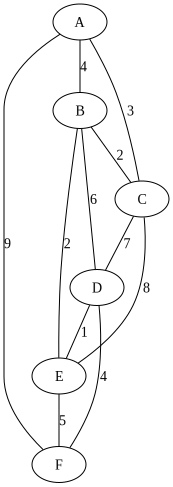

In [2]:
# 가중 그래프 위에 가상의 최단 경로
A, B, C, D, E, F = g.vertices("A", "B", "C", "D", "E", "F")
wg = g.WeightedGraph(
    A - 4 - B - 2 - C - 7 - D - 1 - E - 5 - F,
)
wg += A - 3 - C
wg += B - 6 - D
wg += C - 8 - E
wg += D - 4 - F
wg += A - 9 - F
wg += B - 2 - E

wg

In [ ]:
# dijkstra(wg, A, F) 가 반환했다고 가정한 Path
from core.graph.walk import Path

shortest = A - C - B - E - D - F
print("shortest path:", shortest)
print("weight sum:", sum(wg[e.src, e.dst].weight for e in shortest.edges))

wg._to_graphviz(highlight=shortest)

### 18.2 MST 강조 (Kruskal 결과 가정)

In [ ]:
# kruskal(wg) 가 반환했다고 가정한 부분 그래프
mst = g.WeightedGraph(kind=g.EdgeKind.UNDIRECTED)
mst.add_edge(D, E, 1)
mst.add_edge(B, C, 2)
mst.add_edge(B, E, 2)
mst.add_edge(A, C, 3)
mst.add_edge(D, F, 4)

print("MST edges:", mst.to_edge_list(), "총 가중치:", sum(e[2] for e in mst.to_edge_list()))

wg._to_graphviz(highlight=mst)

### 18.3 BFS / DFS 트래버설 (Walk 결과 가정)

In [ ]:
# bfs(g, A) 가 방문 순서로 만든 Walk 라고 가정
gu = g.Graph.complete(A, B, C, D)

bfs_walk = g.Walk([A - B, B - C, C - D])

gu._to_graphviz(highlight=bfs_walk)

### 18.4 여러 결과 동시 표시 — 자동 색 배분

In [ ]:
# A→F 와 B→D 두 개의 경로를 비교
path1 = Path([A - C, C - B, B - E])
path2 = Path([D - F, F - A])

wg._to_graphviz(highlight=[path1, path2])

In [ ]:
# 격자 그래프에서 두 경로 비교
grid = g.Graph.grid(4, 4)
v = grid.get_vertex
top = g.Walk([v("v00") - v("v01"), v("v01") - v("v02"), v("v02") - v("v03"), v("v03") - v("v13"), v("v13") - v("v23"), v("v23") - v("v33")])
diag = g.Walk([v("v00") - v("v10"), v("v10") - v("v11"), v("v11") - v("v21"), v("v21") - v("v22"), v("v22") - v("v32"), v("v32") - v("v33")])

grid._to_graphviz(highlight=[top, diag])

### 18.5 단일 정점·간선만 있는 경우 (출발·도착 강조)

In [ ]:
# Walk가 정점 하나만 있어도 강조 가능 — 단일 간선 walk로 표현
src_only = g.Walk([A - B])  # A,B만 강조
wg._to_graphviz(highlight=src_only)

### 18.6 SCC / 연결 성분 (부분 그래프 list)

In [ ]:
# scc(g) 가 반환했다고 가정한 강한 연결 성분 list
P, Q, R, S, T, U = g.vertices("P", "Q", "R", "S", "T", "U")
scc_demo = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for u, v in [(P, Q), (Q, R), (R, P),  # 첫 SCC
             (S, T), (T, U), (U, S),  # 둘째 SCC
             (R, S)]:                  # SCC 사이 간선
    scc_demo.add_edge(u, v)

scc1 = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for u, v in [(P, Q), (Q, R), (R, P)]:
    scc1.add_edge(u, v)
scc2 = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for u, v in [(S, T), (T, U), (U, S)]:
    scc2.add_edge(u, v)

scc_demo._to_graphviz(highlight=[scc1, scc2])

### 18.7 FlowGraph — 증가 경로 강조 (Dinic / Ford-Fulkerson)

In [ ]:
# 증가 경로(augmenting path)를 한 색으로 강조
s, t = g.Vertex("s"), g.Vertex("t")
fg = g.FlowGraph.from_edge_list([
    (s, A, 10), (s, B, 8),
    (A, C, 6), (B, C, 5), (B, D, 7),
    (C, t, 9), (D, t, 6),
])

aug = s >> A >> C >> t
fg._to_graphviz(highlight=aug)

### 18.8 매칭 (이분 매칭 결과)

In [ ]:
# 이분 매칭 결과를 부분 그래프로 강조
L1, L2, L3 = g.vertices("L1", "L2", "L3")
R1, R2, R3 = g.vertices("R1", "R2", "R3")

bg = g.Graph.bipartite([L1, L2, L3], [R1, R2, R3])

matching = g.UnweightedGraph()
matching.add_edge(L1, R2)
matching.add_edge(L2, R3)
matching.add_edge(L3, R1)

bg._to_graphviz(highlight=matching)

### 18.9 화살표 — highlight 객체의 edge kind 가 결정

화살표 표시는 **highlight 객체의 ``kind``** 가 정한다 (그래프의 kind를 override):

| highlight | 효과 |
|-----------|------|
| ``Walk([a - b])`` (UNDIRECTED) | 색만, 화살표 없음 |
| ``Walk([a >> b])`` (DIRECTED)  | 매칭 방향에 따라 ``forward`` / ``back`` |
| ``Walk([a & b])`` (BIDIRECTED) | ``both`` (양쪽 화살표) |
| DIRECTED ``UnweightedGraph``   | 모든 edge 에 ``forward`` / ``back`` |

BFS/DFS 트리 같은 분기 구조는 ``Walk`` (연결 강제) 가 아니라 DIRECTED
subgraph 로 표현해야 한다.


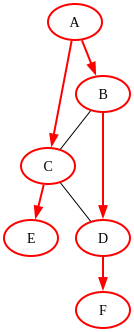

In [4]:
# BFS 트리 — 분기 구조라 Walk 대신 directed subgraph 로 표현
A, B, C, D, E, F = g.vertices("A", "B", "C", "D", "E", "F")
gu = g.UnweightedGraph(A - B - C - D)
gu += A - C
gu += B - D
gu += C - E
gu += D - F

bfs_tree = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for s, t in [(A, B), (A, C), (B, D), (C, E), (D, F)]:
    bfs_tree.add_edge(s, t)
gu._to_graphviz(highlight=bfs_tree)

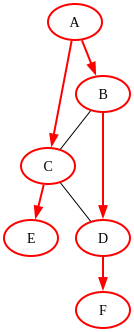

In [5]:
# DFS 트리 — 같은 그래프, 다른 traversal 순서
dfs_tree = g.UnweightedGraph(kind=g.EdgeKind.DIRECTED)
for s, t in [(A, B), (B, D), (D, F), (A, C), (C, E)]:
    dfs_tree.add_edge(s, t)
gu._to_graphviz(highlight=dfs_tree)

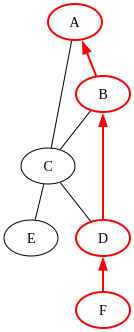

In [6]:
# 역방향 traversal — DIRECTED Walk 로 만들면 화살표가 반대로
back_path = A << B << D << F
gu._to_graphviz(highlight=back_path)

In [ ]:
# 같은 traversal 을 UNDIRECTED Walk 로 만들면 색만 입혀지고 화살표는 없다
plain_path = F - D - B - A
gu._to_graphviz(highlight=plain_path)